In [45]:
!pip install pandas numpy scikit-learn matplotlib seaborn


Defaulting to user installation because normal site-packages is not writeable


# House Price Predictor — Linear Regression
### California Housing Dataset | Maincrafts Technology — Task 1
**Objective:** Train a Linear Regression model to predict median house values using the California Housing dataset.

In [46]:
!pip install --upgrade pandas

Defaulting to user installation because normal site-packages is not writeable


## Step 1: Import Libraries
We import all required libraries for data manipulation, visualization, and machine learning.

In [47]:
# Step 1: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Styling for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load Dataset
20,640 rows of California census data. Target = MedHouseVal (median house value in $100,000s).

In [48]:
# Step 2: Load the California Housing dataset
data = fetch_california_housing(as_frame=True)

# Combine features + target into one DataFrame
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

# Quick look at the data
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Column names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Exploratory Data Analysis (EDA)
Understanding the data before modelling — distributions, missing values, and correlations.

In [49]:
# Step 3: Explore the data
print("=== Basic Info ===")
df.info()

print("\n=== Statistical Summary ===")
df.describe()

=== Basic Info ===
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

=== Statistical Summary ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Step 4: Train/Test Split
80% training, 20% testing. random_state=42 for reproducibility.

In [50]:
# Step 4: Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== Missing Values ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values: 0


## Step 5: Train the Model

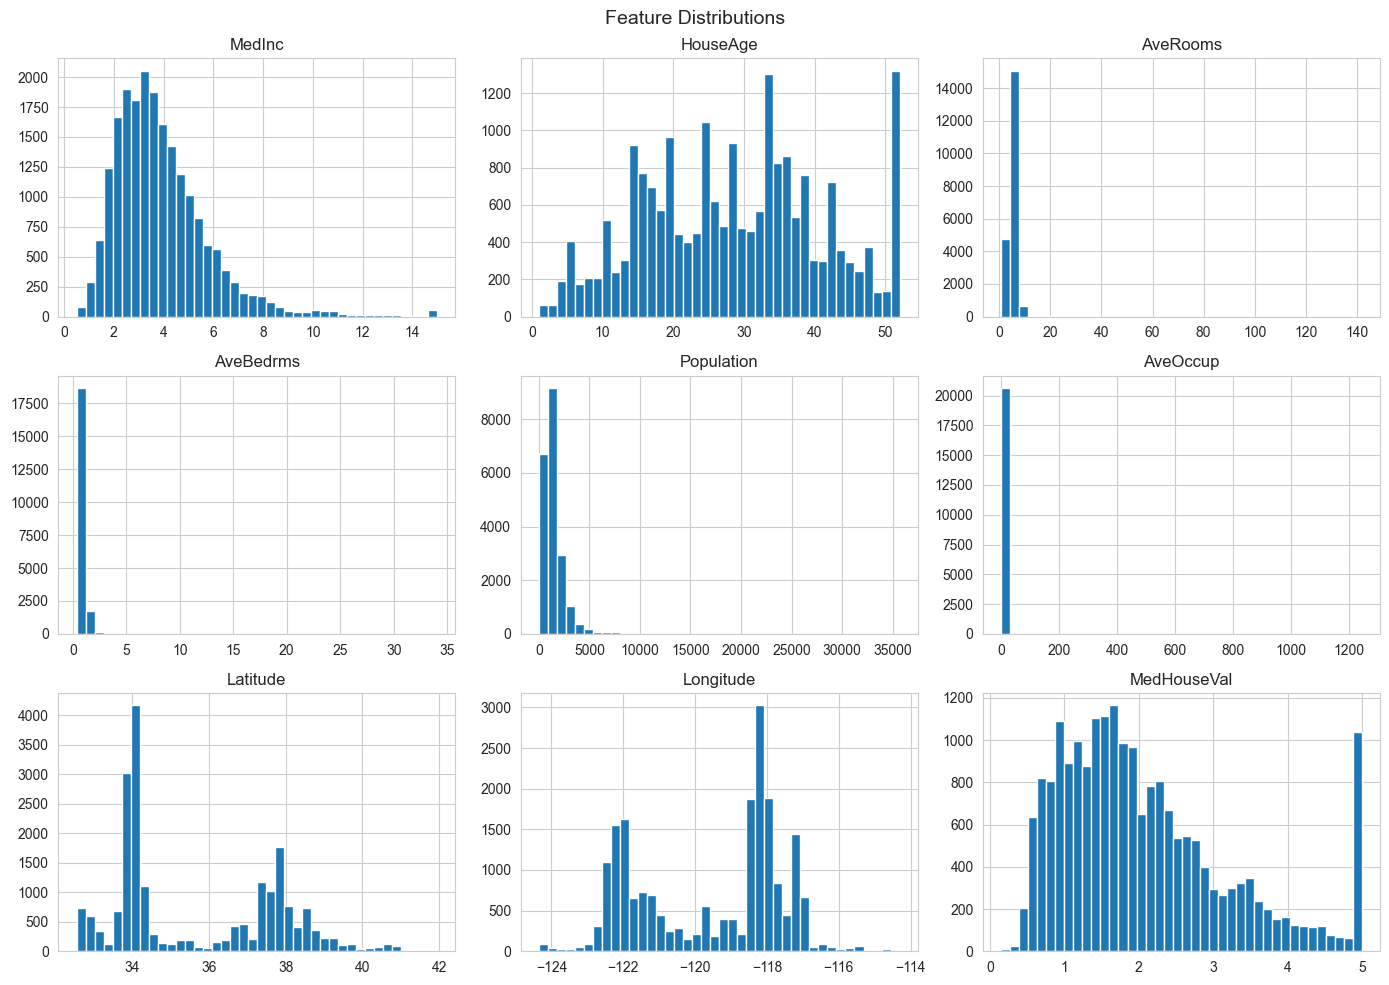

In [51]:
# Step 5: Visualize feature distributions
df.hist(bins=40, figsize=(14, 10))
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("eda_distributions.png")
plt.show()

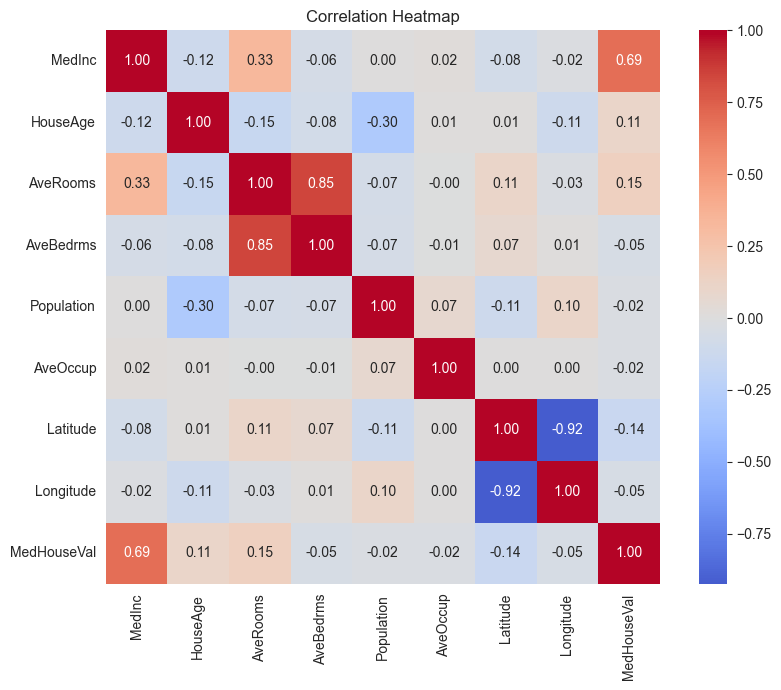

In [52]:
# Step 6: Correlation Heatmap
corr = df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_correlation.png")
plt.show()

In [53]:
# Step 7: Split data into features (X) and target (y)
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows:     {X_test.shape[0]}")
print(f"Features:      {X_train.shape[1]}")

Training rows: 16512
Test rows:     4128
Features:      8


In [54]:
# Step 8: Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

print("Model trained successfully!")
print(f"\nModel coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:12s}: {coef:.4f}")
print(f"  {'Intercept':12s}: {model.intercept_:.4f}")

Model trained successfully!

Model coefficients:
  MedInc      : 0.4487
  HouseAge    : 0.0097
  AveRooms    : -0.1233
  AveBedrms   : 0.7831
  Population  : -0.0000
  AveOccup    : -0.0035
  Latitude    : -0.4198
  Longitude   : -0.4337
  Intercept   : -37.0233


## Step 6: Model Evaluation
MAE, RMSE, and R² scored on the unseen test set.

In [55]:
# Step 9: Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}  → avg error of ${mae*100000:,.0f}")
print(f"RMSE: {rmse:.4f}  → ${rmse*100000:,.0f}")
print(f"R2:   {r2:.4f}  → model explains {r2*100:.1f}% of variance")

MAE:  0.5332  → avg error of $53,320
RMSE: 0.7456  → $74,558
R2:   0.5758  → model explains 57.6% of variance


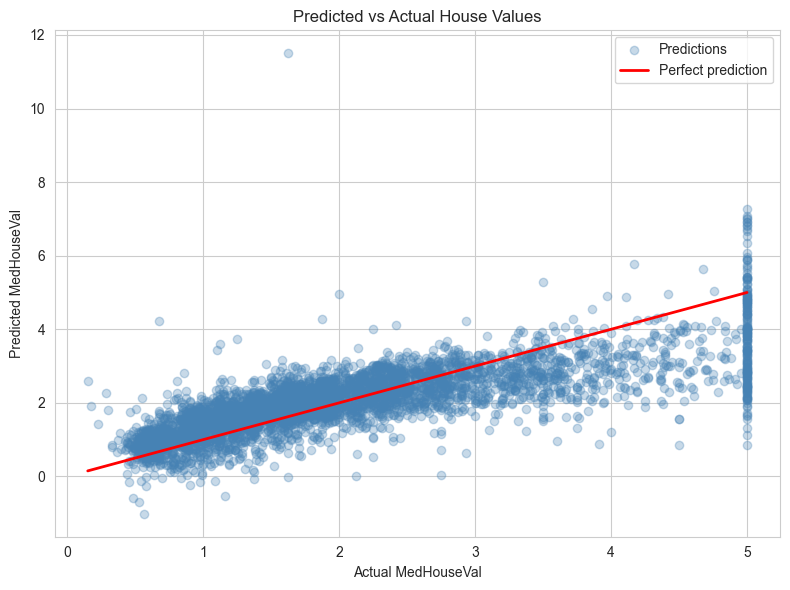

In [56]:
# Step 10: Predicted vs Actual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', label='Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect prediction')
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Predicted vs Actual House Values")
plt.legend()
plt.tight_layout()
plt.savefig("pred_vs_actual.png")
plt.show()

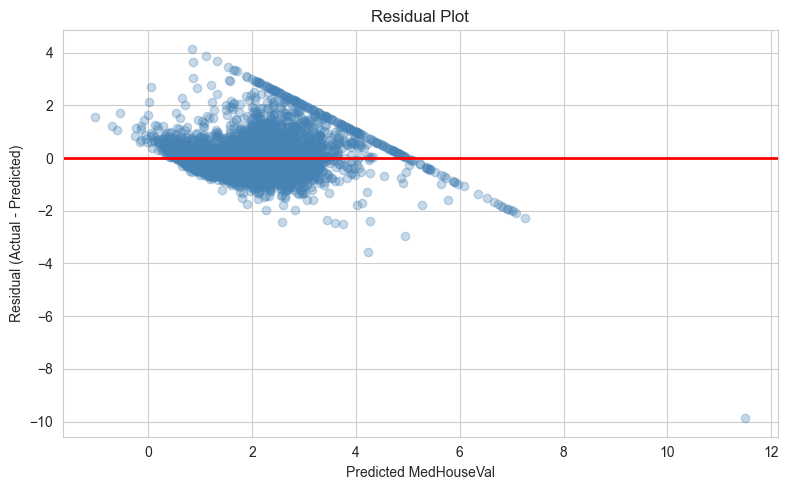

In [57]:
# Step 11: Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='steelblue')
plt.axhline(y=0, color='red', linewidth=2)
plt.xlabel("Predicted MedHouseVal")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig("residuals.png")
plt.show()

In [58]:
# Step 12: Save the trained model
joblib.dump(model, 'house_price_model.pkl')
print("Model saved as house_price_model.pkl")

# Test loading it back
loaded_model = joblib.load('house_price_model.pkl')
print("Model loaded back successfully!")

# Quick prediction test
import pandas as pd
sample = pd.DataFrame([{
    'MedInc': 5.0, 'HouseAge': 25, 'AveRooms': 6.0,
    'AveBedrms': 1.0, 'Population': 1200, 'AveOccup': 3.0,
    'Latitude': 34.1, 'Longitude': -118.3
}])
prediction = loaded_model.predict(sample)[0]
print(f"Test prediction: ${prediction*100000:,.0f}")

Model saved as house_price_model.pkl
Model loaded back successfully!
Test prediction: $248,613


## Summary
- **MAE:** $53,320 average error
- **RMSE:** $74,558
- **R²:** 57.6% variance explained
- **Key finding:** MedInc is the strongest predictor (correlation = 0.69)
- **Improvement ideas:** Try Random Forest or XGBoost for better accuracy